# Manual Graph of Thoughts Demo: Merge Docs with Simulated Language Model
This example shows how to use the `pure_graph_of_thoughts` package for manual graph of operations construction using the simulated Language Model.

The example task `merge_docs` (defined in `merge_docs.py`) is used.

## Construct Graph of Operations
The graph of operations is constructed.

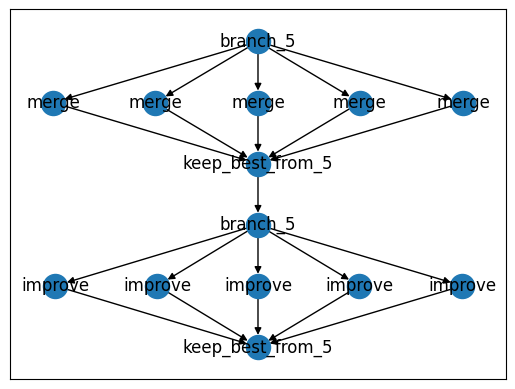

In [5]:
from typing import Sequence

from pure_graph_of_thoughts.api.graph.operation import OperationNode, GraphOfOperations
from pure_graph_of_thoughts.api.state import State
from pure_graph_of_thoughts.visualization import plot_graph

from reinforced_graph_of_thoughts.tasks.merge_docs import create_op_merge, create_op_improve, op_branch_5, \
    create_op_keep_best_from_5


def score_has_content(
        cumulative_score: float, previous_state: State, current_state: State, output_states: Sequence[State]
) -> float:
    if cumulative_score < 0.0:
        return -1.0
    return 1.0 if current_state.get('merged') else -1.0

def score_compare_has_content(state: State, _: Sequence[State]) -> float:
    return 1.0 if state.get('merged') else -1.0

op_merge = create_op_merge(score_has_content)
op_improve = create_op_improve(score_has_content)
op_keep_best_from_5 = create_op_keep_best_from_5(score_compare_has_content)

def _create_merge_docs_graph_of_operations() -> GraphOfOperations:
    source = OperationNode.of(op_branch_5)

    merge_nodes = []
    for _ in range(5):
        merge_node = source.append_operation(op_merge)
        merge_nodes.append(merge_node)

    keep_best = OperationNode.of(op_keep_best_from_5)
    for merge_node in merge_nodes:
        merge_node.append(keep_best)

    improve_branches = keep_best.append_operation(op_branch_5)
    improve_nodes = []
    for _ in range(5):
        improve_node = improve_branches.append_operation(op_improve)
        improve_nodes.append(improve_node)

    keep_best_final = OperationNode.of(op_keep_best_from_5)
    for improve_node in improve_nodes:
        improve_node.append(keep_best_final)

    return GraphOfOperations.from_source(source)


merge_docs_graph_of_operations: GraphOfOperations = _create_merge_docs_graph_of_operations()
plot_graph(merge_docs_graph_of_operations)

## Execute Graph of Operations
A simulated language model is used as the executing language model.

In [6]:
from reinforced_graph_of_thoughts.language_model.simulated_chat_gpt_merge_docs import \
    create_simulated_realistic_chat_gpt_merge_docs
from pure_graph_of_thoughts.controller import CompleteGraphController
import logging

logging.basicConfig(level=logging.INFO)

SEED = 0

ctrl = CompleteGraphController(
    language_model=create_simulated_realistic_chat_gpt_merge_docs(SEED, extra_args={})
)

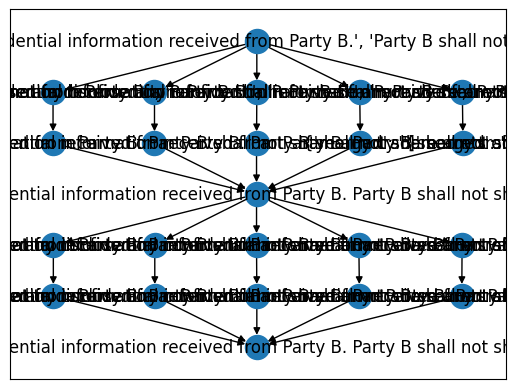

In [7]:
documents = [
    'Party A agrees not to disclose any confidential information received from Party B.',
    'Party B shall not share any trade secrets of Party A with third parties.',
]
merge_docs_graph_of_thoughts = ctrl.execute_graph(merge_docs_graph_of_operations, init_state={
    'documents': documents
})
plot_graph(merge_docs_graph_of_thoughts)

In [8]:
merge_docs_graph_of_thoughts.sinks[0].thought.state

{'merged': 'Party A agrees not to disclose any confidential information received from Party B. Party B shall not share any trade secrets of Party A with third parties.'}